In [1]:
import random
from pathlib import Path

import numpy as np
import torch

DATA_DIR = Path("output")

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed()

In [2]:
dataset_path = Path("output/dataset_winsize1h_where.csv")

In [3]:
import json

import pandas as pd

where_df = pd.read_csv(
    dataset_path,
    dtype={"fold_id": "int64"},
    converters={
        "window": json.loads,
        "label": json.loads,
    },
)
where_df = where_df.loc[~where_df["is_bg"]].drop(columns="is_bg")

where_df.head()

,fold_id,window,label
0,2,"[{'from_zone_index': 16, 'to_zone_index': 16, ...","{'from_zone_index': 12, 'to_zone_index': 12}"
1,2,"[{'from_zone_index': 9, 'to_zone_index': 9, 'o...","{'from_zone_index': 17, 'to_zone_index': 17}"
5,3,"[{'from_zone_index': 0, 'to_zone_index': 0, 'o...","{'from_zone_index': 8, 'to_zone_index': 8}"
8,-1,"[{'from_zone_index': 4, 'to_zone_index': 4, 'o...","{'from_zone_index': 2, 'to_zone_index': 2}"
9,4,"[{'from_zone_index': 8, 'to_zone_index': 5, 'o...","{'from_zone_index': 2, 'to_zone_index': 2}"


In [4]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

OUTAGE_TYPE_TO_ID = {
    "Planned": 0,
    "Auto": 1,
}


class WhereOutageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        window = row["window"]
        label = row["label"]

        outage_type = torch.tensor(
            [OUTAGE_TYPE_TO_ID[event["outage_type"]] for event in window],
            dtype=torch.long,
        )
        from_zone_indices = torch.tensor(
            [event["from_zone_index"] for event in window],
            dtype=torch.long,
        )
        to_zone_indices = torch.tensor(
            [event["to_zone_index"] for event in window],
            dtype=torch.long,
        )
        time_interval_index = torch.tensor(
            [event["time_interval_index"] for event in window],
            dtype=torch.long,
        )
        target = torch.tensor(
            [label["from_zone_index"], label["to_zone_index"]],
            dtype=torch.long,
        )

        return {
            "outage_type": outage_type,
            "from_zone_indices": from_zone_indices,
            "to_zone_indices": to_zone_indices,
            "time_interval_index": time_interval_index,
            "target": target,
        }


TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLDS = [-1]

train_where_dataset = WhereOutageDataset(
    where_df[where_df["fold_id"].isin(TRAIN_FOLDS)]
)
test_where_dataset = WhereOutageDataset(where_df[where_df["fold_id"].isin(TEST_FOLDS)])

In [5]:
for i, sample_dict in enumerate(train_where_dataset):
    print(sample_dict)
    if i == 10:
        break

{'outage_type': tensor([0]), 'from_zone_indices': tensor([16]), 'to_zone_indices': tensor([16]), 'time_interval_index': tensor([2]), 'target': tensor([12, 12])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([9]), 'to_zone_indices': tensor([9]), 'time_interval_index': tensor([1]), 'target': tensor([17, 17])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([0]), 'to_zone_indices': tensor([0]), 'time_interval_index': tensor([2]), 'target': tensor([8, 8])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([8]), 'to_zone_indices': tensor([5]), 'time_interval_index': tensor([3]), 'target': tensor([2, 2])}
{'outage_type': tensor([0, 0, 0]), 'from_zone_indices': tensor([1, 2, 2]), 'to_zone_indices': tensor([16,  2,  2]), 'time_interval_index': tensor([2, 2, 1]), 'target': tensor([2, 2])}
{'outage_type': tensor([1, 0]), 'from_zone_indices': tensor([9, 8]), 'to_zone_indices': tensor([9, 8]), 'time_interval_index': tensor([4, 3]), 'target': tensor([21, 21])}
{'outage_ty

In [6]:
from tqdm import tqdm as tdqm

num_time_intervals = 0
for sample_dict in tdqm(train_where_dataset):
    num_time_intervals = max(
        num_time_intervals, sample_dict["time_interval_index"].max().item() + 1
    )
print(f"{num_time_intervals = }")

100%|██████████| 2967/2967 [00:00<00:00, 34667.34it/s]

num_time_intervals = 5


# Models definition

In [7]:
ZONE_EMBEDDING_DIM = 256
OUTAGE_TYPE_EMBEDDING_DIM = 64
TIME_INTERVAL_EMBEDDING_DIM = 64
TRANSFORMER_DIM = 512
DROPOUT = 0.15

In [8]:
import torch.nn as nn

num_zones = int(
    max(
        where_df["label"]
        .map(lambda x: max(x["from_zone_index"], x["to_zone_index"]))
        .max(),
        max(
            max(event["from_zone_index"], event["to_zone_index"])
            for window in where_df["window"]
            for event in window
        ),
    )
    + 1
)
num_outage_types = len(OUTAGE_TYPE_TO_ID)


class WhereTransformer(nn.Module):
    """ "Vanilla transformer model"""

    def __init__(
        self,
        num_zones,
        num_outage_types,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        time_interval_embedding_dim=TIME_INTERVAL_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.num_zones = num_zones
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types,
            outage_type_embedding_dim,
        )
        self.time_interval_embedding = nn.Embedding(
            num_time_intervals,
            time_interval_embedding_dim,
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim
            + outage_type_embedding_dim
            + time_interval_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )
        self.projection = nn.Linear(transformer_dim, 2 * num_zones)

    def forward(
        self,
        from_zone_indices,
        to_zone_indices,
        outage_type,
        time_interval_index,
    ):
        from_zone_emb = self.zone_embedding(from_zone_indices)
        to_zone_emb = self.zone_embedding(to_zone_indices)
        outage_type_emb = self.outage_type_embedding(outage_type)
        time_interval_emb = self.time_interval_embedding(time_interval_index)

        x = torch.cat(
            [from_zone_emb, to_zone_emb, outage_type_emb, time_interval_emb],
            dim=-1,
        )
        x = self.input_fc(x)

        x = self.transformer_encoder(x)

        # AVerage pooling over the time dimension (dim=1)
        # pooled = x.mean(dim=1)
        # Use the last time step's output for pooling
        pooled = x[:, -1, :]

        logits = self.projection(pooled)
        return logits.view(-1, 2, self.num_zones)

In [9]:
class GraphDistanceUnorderedZoneLoss(nn.Module):
    def __init__(
        self,
        graph,
        num_zones,
        distance_weight=0.2,
        unreachable_distance=None,
        reduction="mean",
    ):
        super().__init__()
        self.num_zones = num_zones
        self.distance_weight = distance_weight
        self.reduction = reduction

        distance_matrix = torch.as_tensor(
            graph.distances(
                source=range(num_zones),
                target=range(num_zones),
                mode="ALL",
            ),
            dtype=torch.float32,
        )
        finite_distances = distance_matrix[torch.isfinite(distance_matrix)]
        if unreachable_distance is None:
            unreachable_distance = finite_distances.max().item() + 1.0
        distance_matrix = torch.where(
            torch.isfinite(distance_matrix),
            distance_matrix,
            torch.full_like(distance_matrix, float(unreachable_distance)),
        )
        self.register_buffer("distance_matrix", distance_matrix)

    def _ordered_loss(self, from_logits, to_logits, target_from, target_to):
        ce_loss = nn.functional.cross_entropy(
            from_logits,
            target_from,
            reduction="none",
        ) + nn.functional.cross_entropy(
            to_logits,
            target_to,
            reduction="none",
        )

        from_probs = nn.functional.softmax(from_logits, dim=-1)
        to_probs = nn.functional.softmax(to_logits, dim=-1)
        from_distance = (from_probs * self.distance_matrix[target_from]).sum(dim=-1)
        to_distance = (to_probs * self.distance_matrix[target_to]).sum(dim=-1)
        distance_loss = from_distance + to_distance

        return ce_loss + self.distance_weight * distance_loss

    def forward(self, logits, target):
        from_logits = logits[:, 0, :]
        to_logits = logits[:, 1, :]
        target_from = target[:, 0]
        target_to = target[:, 1]

        forward_loss = self._ordered_loss(
            from_logits,
            to_logits,
            target_from,
            target_to,
        )
        swapped_loss = self._ordered_loss(
            from_logits,
            to_logits,
            target_to,
            target_from,
        )
        loss = torch.minimum(forward_loss, swapped_loss)

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        if self.reduction == "none":
            return loss
        raise ValueError(f"Unsupported reduction: {self.reduction}")

In [10]:
class SelfAttentivePooling(nn.Module):
    def __init__(self, input_dim, attention_dim=None, dropout=DROPOUT):
        super().__init__()
        attention_dim = attention_dim or input_dim
        self.attention = nn.Sequential(
            nn.Linear(input_dim, attention_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attention_dim, 1),
        )

    def forward(self, x):
        attention_scores = self.attention(x).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)
        return (x * attention_weights).sum(dim=1)


class WhereTransformerSAP(nn.Module):
    def __init__(
        self,
        num_zones,
        num_outage_types,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        time_interval_embedding_dim=TIME_INTERVAL_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.num_zones = num_zones
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types,
            outage_type_embedding_dim,
        )
        self.time_interval_embedding = nn.Embedding(
            num_time_intervals,
            time_interval_embedding_dim,
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim
            + outage_type_embedding_dim
            + time_interval_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )
        self.self_attentive_pooling = SelfAttentivePooling(
            transformer_dim,
            dropout=dropout,
        )
        self.projection = nn.Linear(transformer_dim, 2 * num_zones)

    def forward(
        self,
        from_zone_indices,
        to_zone_indices,
        outage_type,
        time_interval_index,
    ):
        from_zone_emb = self.zone_embedding(from_zone_indices)
        to_zone_emb = self.zone_embedding(to_zone_indices)
        outage_type_emb = self.outage_type_embedding(outage_type)
        time_interval_emb = self.time_interval_embedding(time_interval_index)

        x = torch.cat(
            [from_zone_emb, to_zone_emb, outage_type_emb, time_interval_emb],
            dim=-1,
        )
        x = self.input_fc(x)

        x = self.transformer_encoder(x)

        pooled = self.self_attentive_pooling(x)

        logits = self.projection(pooled)
        return logits.view(-1, 2, self.num_zones)

# Vanilla Model training

In [11]:
LEARNING_RATE = 3e-6
NUM_EPOCHS = 64
VIRTUAL_BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_to_device(sample, device):
    return {
        "from_zone_indices": sample["from_zone_indices"].unsqueeze(0).to(device),
        "to_zone_indices": sample["to_zone_indices"].unsqueeze(0).to(device),
        "outage_type": sample["outage_type"].unsqueeze(0).to(device),
        "time_interval_index": sample["time_interval_index"].unsqueeze(0).to(device),
        "target": sample["target"].unsqueeze(0).to(device),
    }


def unordered_zone_loss(logits, target):
    from_logits = logits[:, 0, :]
    to_logits = logits[:, 1, :]
    target_from = target[:, 0]
    target_to = target[:, 1]

    forward_loss = nn.functional.cross_entropy(
        from_logits,
        target_from,
    ) + nn.functional.cross_entropy(
        to_logits,
        target_to,
    )
    swapped_loss = nn.functional.cross_entropy(
        from_logits,
        target_to,
    ) + nn.functional.cross_entropy(
        to_logits,
        target_from,
    )
    return torch.minimum(forward_loss, swapped_loss).mean()


def unordered_zone_correct_count(logits, target):
    pred = logits.argmax(dim=-1)
    pred_sorted = torch.sort(pred, dim=1).values
    target_sorted = torch.sort(target, dim=1).values
    return (pred_sorted == target_sorted).all(dim=1).sum().item()


set_seed()
where_transformer = WhereTransformer(
    num_zones=num_zones,
    num_outage_types=num_outage_types,
)
where_transformer.to(DEVICE)
optimizer = torch.optim.Adam(where_transformer.parameters(), lr=LEARNING_RATE)

training_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    where_transformer.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    accumulated_samples = 0
    train_order = torch.randperm(len(train_where_dataset)).tolist()

    for sample_idx in train_order:
        batch = sample_to_device(train_where_dataset[sample_idx], DEVICE)
        logits = where_transformer(
            batch["from_zone_indices"],
            batch["to_zone_indices"],
            batch["outage_type"],
            batch["time_interval_index"],
        )
        loss = unordered_zone_loss(logits, batch["target"])
        loss.backward()

        train_loss_sum += loss.item()
        train_correct += unordered_zone_correct_count(logits, batch["target"])
        train_count += 1
        accumulated_samples += 1

        if accumulated_samples == VIRTUAL_BATCH_SIZE:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            accumulated_samples = 0

    if accumulated_samples:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    train_loss = train_loss_sum / train_count
    train_accuracy = train_correct / train_count

    where_transformer.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_count = 0

    with torch.no_grad():
        for sample_idx in range(len(test_where_dataset)):
            batch = sample_to_device(test_where_dataset[sample_idx], DEVICE)
            logits = where_transformer(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["time_interval_index"],
            )
            loss = unordered_zone_loss(logits, batch["target"])

            test_loss_sum += loss.item()
            test_correct += unordered_zone_correct_count(logits, batch["target"])
            test_count += 1

    test_loss = test_loss_sum / test_count
    test_accuracy = test_correct / test_count

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    training_history.append(epoch_metrics)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train acc={train_accuracy:.4f} | "
        f"test loss={test_loss:.6f}, test acc={test_accuracy:.4f}"
    )

MODEL_OUTPUT_DIR = OUTPUT_DIR / "where_transformer"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
mean_pooling_ce_checkpoint_path = (
    MODEL_OUTPUT_DIR / "where_transformer_cross_entropy_mean_pooling_last.pt"
)

torch.save(
    {
        "model_state_dict": where_transformer.state_dict(),
        "num_zones": num_zones,
        "num_outage_types": num_outage_types,
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
        "transformer_dim": TRANSFORMER_DIM,
        "dropout": DROPOUT,
        "outage_type_to_id": OUTAGE_TYPE_TO_ID,
        "training_history": training_history,
    },
    mean_pooling_ce_checkpoint_path,
)

print(
    f"Saved final cross-entropy mean-pooling checkpoint to {mean_pooling_ce_checkpoint_path}"
)

/home/aj/venv/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001 | train loss=6.536184, train acc=0.0003 | test loss=6.205161, test acc=0.0013
Epoch 002 | train loss=5.952202, train acc=0.0398 | test loss=5.711901, test acc=0.0981
Epoch 003 | train loss=5.603163, train acc=0.1254 | test loss=5.438474, test acc=0.1519
Epoch 004 | train loss=5.394364, train acc=0.1581 | test loss=5.276935, test acc=0.1855
Epoch 005 | train loss=5.269987, train acc=0.1807 | test loss=5.167928, test acc=0.2043
Epoch 006 | train loss=5.176278, train acc=0.1972 | test loss=5.089586, test acc=0.2056
Epoch 007 | train loss=5.090771, train acc=0.2123 | test loss=5.031413, test acc=0.2258
Epoch 008 | train loss=5.039437, train acc=0.2211 | test loss=4.985103, test acc=0.2446
Epoch 009 | train loss=4.995104, train acc=0.2282 | test loss=4.948859, test acc=0.2473
Epoch 010 | train loss=4.953937, train acc=0.2319 | test loss=4.918354, test acc=0.2446
Epoch 011 | train loss=4.918398, train acc=0.2336 | test loss=4.891586, test acc=0.2527
Epoch 012 | train loss=4.884110,

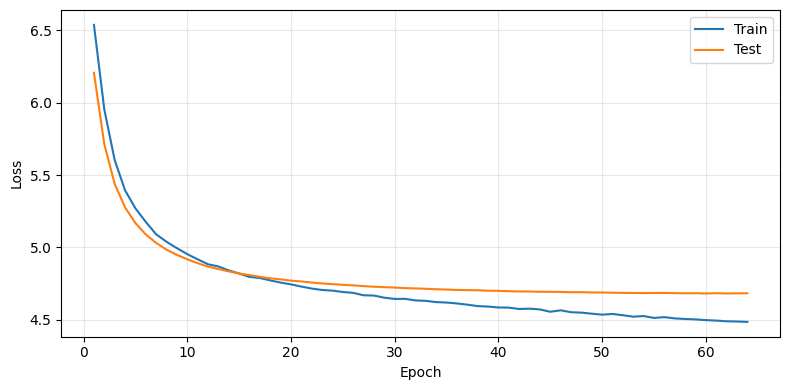

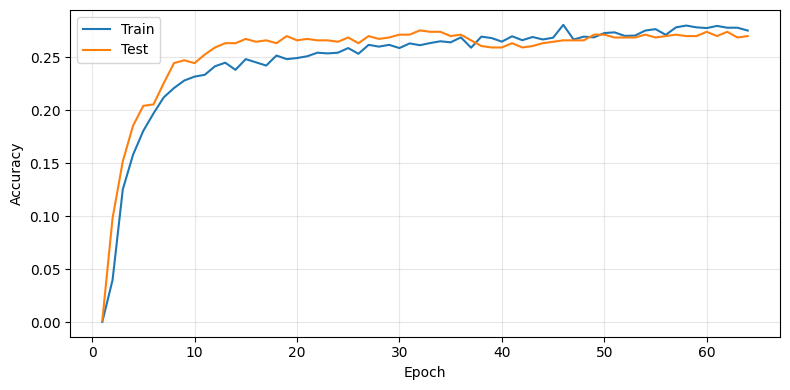

In [12]:
import matplotlib.pyplot as plt

epochs = [row["epoch"] for row in training_history]
train_losses = [row["train_loss"] for row in training_history]
test_losses = [row["test_loss"] for row in training_history]
train_accuracies = [row["train_accuracy"] for row in training_history]
test_accuracies = [row["test_accuracy"] for row in training_history]

plt.figure(figsize=(8, 4))

plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
# plt.title("Training and test loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "where_training_loss.pdf", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))

plt.plot(epochs, train_accuracies, label="Train")
plt.plot(epochs, test_accuracies, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
# plt.title("Training and test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "where_training_accuracy.pdf", dpi=300)
plt.show()

Loaded model checkpoint from model_outputs/where_transformer/where_transformer_cross_entropy_mean_pooling_last.pt
Raw outage graph: 1376 nodes, 2194 edges
Maximum raw graph node distance: 27
Random raw nodes 122 -> 1064 distance: 4
Maximum zone graph distance: 5
Random zones 10 -> 23 distance: 5
Average unordered zone-pair distance, model: 1.694
Average unordered zone-pair distance, random baseline: 2.365
Model mean unordered pair distance: 1.694 / 5 (33.9% of zone diameter)
Distance reduction versus random zone-pair baseline: 28.4%


,model,mean_distance,median_distance,p90_distance,same_zone_pair_rate,adjacent_or_same_pair_rate,unreachable_count,exact_pair_accuracy,mean_distance_vs_diameter,mean_distance_reduction_vs_random
0,Transformer,1.694,2.0,4.0,0.270,0.392,0,0.27,0.339,0.284
1,Random zone-pair baseline,2.364,2.5,3.5,0.002,0.064,0,NaN,NaN,NaN


,true_from_zone,true_to_zone,pred_from_zone,pred_to_zone,exact_pair_match
0,2,2,18,18,False
1,9,9,2,2,False
2,10,10,10,10,True
3,10,10,18,18,False
4,10,10,10,10,True


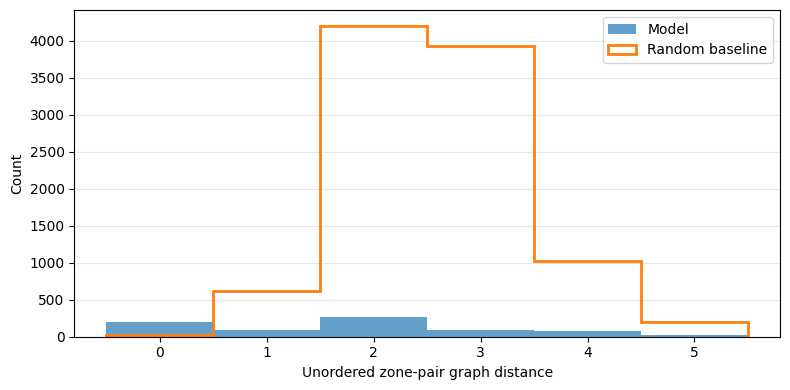

In [13]:
from collections import deque
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

GRAPH_PATH = Path("res/outage_graph.pkl")
EDGE_ZONE_PATH = Path("output/edge_zones.csv")
RANDOM_PAIR_BASELINE_SIZE = 10_000


def build_zone_distance_lookup(edge_zone_path):
    edge_zone_df = pd.read_csv(edge_zone_path)
    zones = sorted(
        set(edge_zone_df["from_zone"].astype(int))
        | set(edge_zone_df["to_zone"].astype(int))
    )
    adjacency = {zone: {zone} for zone in zones}

    for from_zone, to_zone in zip(
        edge_zone_df["from_zone"].astype(int),
        edge_zone_df["to_zone"].astype(int),
    ):
        adjacency.setdefault(from_zone, {from_zone}).add(to_zone)
        adjacency.setdefault(to_zone, {to_zone}).add(from_zone)

    distances = {}
    for source in adjacency:
        source_distances = {source: 0}
        queue = deque([source])
        while queue:
            current = queue.popleft()
            for neighbor in adjacency[current]:
                if neighbor not in source_distances:
                    source_distances[neighbor] = source_distances[current] + 1
                    queue.append(neighbor)
        distances[source] = source_distances

    return distances


def zone_distance(source_zone, target_zone, distance_lookup):
    return distance_lookup.get(int(source_zone), {}).get(int(target_zone), np.nan)


def unordered_pair_graph_distance(true_pair, pred_pair, distance_lookup):
    direct = (
        zone_distance(true_pair[0], pred_pair[0], distance_lookup)
        + zone_distance(true_pair[1], pred_pair[1], distance_lookup)
    ) / 2
    swapped = (
        zone_distance(true_pair[0], pred_pair[1], distance_lookup)
        + zone_distance(true_pair[1], pred_pair[0], distance_lookup)
    ) / 2
    candidates = [distance for distance in [direct, swapped] if np.isfinite(distance)]
    return min(candidates) if candidates else np.nan


def summarize_pair_distances(distances):
    distances = np.asarray(distances, dtype=float)
    finite = distances[np.isfinite(distances)]
    return {
        "mean_distance": finite.mean(),
        "median_distance": np.median(finite),
        "p90_distance": np.percentile(finite, 90),
        "same_zone_pair_rate": (finite == 0).mean(),
        "adjacent_or_same_pair_rate": (finite <= 1).mean(),
        "unreachable_count": int(np.isnan(distances).sum()),
    }


logits = where_transformer(
    batch["from_zone_indices"],
    batch["to_zone_indices"],
    batch["outage_type"],
    batch["time_interval_index"],
)


def collect_where_predictions(model, dataset, device):
    model.eval()
    rows = []
    with torch.no_grad():
        for sample in dataset:
            batch = sample_to_device(sample, device)
            logits = model(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["time_interval_index"],
            )
            pred_pair = logits.argmax(dim=-1).squeeze(0).cpu().tolist()
            true_pair = sample["target"].cpu().tolist()
            rows.append(
                {
                    "true_from_zone": int(true_pair[0]),
                    "true_to_zone": int(true_pair[1]),
                    "pred_from_zone": int(pred_pair[0]),
                    "pred_to_zone": int(pred_pair[1]),
                    "exact_pair_match": sorted(true_pair) == sorted(pred_pair),
                }
            )
    return pd.DataFrame(rows)


outage_graph = ig.Graph.Read_Pickle(str(GRAPH_PATH))
zone_distance_lookup = build_zone_distance_lookup(EDGE_ZONE_PATH)
zone_ids = sorted(zone_distance_lookup)
rng = np.random.default_rng(RANDOM_STATE)

raw_graph_diameter = outage_graph.diameter(directed=False, unconn=True)
node_a, node_b = rng.choice(outage_graph.vcount(), size=2, replace=False)
random_node_distance = outage_graph.distances(
    source=[int(node_a)],
    target=[int(node_b)],
    mode="ALL",
)[0][0]

zone_graph_diameter = max(
    distance
    for source_distances in zone_distance_lookup.values()
    for distance in source_distances.values()
)
zone_a, zone_b = rng.choice(zone_ids, size=2, replace=False)
random_zone_distance = zone_distance_lookup[int(zone_a)][int(zone_b)]

checkpoint_path = Path(
    globals().get(
        "mean_pooling_ce_checkpoint_path",
        OUTPUT_DIR
        / "where_transformer"
        / "where_transformer_cross_entropy_mean_pooling_last.pt",
    )
)
if checkpoint_path.exists():
    try:
        checkpoint = torch.load(
            checkpoint_path, map_location=DEVICE, weights_only=False
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    where_transformer.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded model checkpoint from {checkpoint_path}")
else:
    print("No saved checkpoint found; evaluating the current in-memory model.")

prediction_df = collect_where_predictions(where_transformer, test_where_dataset, DEVICE)
pair_distances = np.asarray(
    [
        unordered_pair_graph_distance(
            (row.true_from_zone, row.true_to_zone),
            (row.pred_from_zone, row.pred_to_zone),
            zone_distance_lookup,
        )
        for row in prediction_df.itertuples(index=False)
    ],
    dtype=float,
)

random_pair_distances = np.asarray(
    [
        unordered_pair_graph_distance(
            tuple(
                prediction_df.iloc[i % len(prediction_df)][
                    ["true_from_zone", "true_to_zone"]
                ].to_numpy()
            ),
            rng.choice(zone_ids, size=2, replace=True),
            zone_distance_lookup,
        )
        for i in range(RANDOM_PAIR_BASELINE_SIZE)
    ],
    dtype=float,
)

model_summary = summarize_pair_distances(pair_distances)
random_summary = summarize_pair_distances(random_pair_distances)
model_summary["exact_pair_accuracy"] = prediction_df["exact_pair_match"].mean()
model_summary["mean_distance_vs_diameter"] = (
    model_summary["mean_distance"] / zone_graph_diameter
)
model_summary["mean_distance_reduction_vs_random"] = 1 - (
    model_summary["mean_distance"] / random_summary["mean_distance"]
)

summary_df = pd.DataFrame(
    [
        {"model": "Transformer", **model_summary},
        {"model": "Random zone-pair baseline", **random_summary},
    ]
)

print(f"Raw outage graph: {outage_graph.vcount()} nodes, {outage_graph.ecount()} edges")
print(f"Maximum raw graph node distance: {raw_graph_diameter}")
print(
    f"Random raw nodes {int(node_a)} -> {int(node_b)} distance: "
    f"{random_node_distance}"
)
print(f"Maximum zone graph distance: {zone_graph_diameter}")
print(f"Random zones {int(zone_a)} -> {int(zone_b)} distance: {random_zone_distance}")
print(
    "Average unordered zone-pair distance, model: "
    f"{model_summary['mean_distance']:.3f}"
)
print(
    "Average unordered zone-pair distance, random baseline: "
    f"{random_summary['mean_distance']:.3f}"
)
print(
    "Model mean unordered pair distance: "
    f"{model_summary['mean_distance']:.3f} / {zone_graph_diameter} "
    f"({model_summary['mean_distance_vs_diameter']:.1%} of zone diameter)"
)
print(
    "Distance reduction versus random zone-pair baseline: "
    f"{model_summary['mean_distance_reduction_vs_random']:.1%}"
)

display(summary_df.round(3))
display(prediction_df.head())

bins = np.arange(-0.5, zone_graph_diameter + 1.5, 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    pair_distances[np.isfinite(pair_distances)], bins=bins, alpha=0.7, label="Model"
)
ax.hist(
    random_pair_distances[np.isfinite(random_pair_distances)],
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Random baseline",
)
ax.set_xlabel("Unordered zone-pair graph distance")
ax.set_ylabel("Count")
# ax.set_title("Where-model graph-distance error")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "where_graph_distance_error.pdf", dpi=300)
plt.show()

# SAP model

In [14]:
LEARNING_RATE = 3e-6
NUM_EPOCHS = 64
VIRTUAL_BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_to_device(sample, device):
    return {
        "from_zone_indices": sample["from_zone_indices"].unsqueeze(0).to(device),
        "to_zone_indices": sample["to_zone_indices"].unsqueeze(0).to(device),
        "outage_type": sample["outage_type"].unsqueeze(0).to(device),
        "time_interval_index": sample["time_interval_index"].unsqueeze(0).to(device),
        "target": sample["target"].unsqueeze(0).to(device),
    }


def unordered_zone_loss(logits, target):
    from_logits = logits[:, 0, :]
    to_logits = logits[:, 1, :]
    target_from = target[:, 0]
    target_to = target[:, 1]

    forward_loss = nn.functional.cross_entropy(
        from_logits,
        target_from,
    ) + nn.functional.cross_entropy(
        to_logits,
        target_to,
    )
    swapped_loss = nn.functional.cross_entropy(
        from_logits,
        target_to,
    ) + nn.functional.cross_entropy(
        to_logits,
        target_from,
    )
    return torch.minimum(forward_loss, swapped_loss).mean()


def unordered_zone_correct_count(logits, target):
    pred = logits.argmax(dim=-1)
    pred_sorted = torch.sort(pred, dim=1).values
    target_sorted = torch.sort(target, dim=1).values
    return (pred_sorted == target_sorted).all(dim=1).sum().item()


where_transformer_sap = WhereTransformerSAP(
    num_zones=num_zones,
    num_outage_types=num_outage_types,
)
where_transformer_sap
where_transformer_sap.to(DEVICE)
optimizer = torch.optim.Adam(where_transformer_sap.parameters(), lr=LEARNING_RATE)

training_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    where_transformer_sap.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    accumulated_samples = 0
    train_order = torch.randperm(len(train_where_dataset)).tolist()

    for sample_idx in train_order:
        batch = sample_to_device(train_where_dataset[sample_idx], DEVICE)
        logits = where_transformer_sap(
            batch["from_zone_indices"],
            batch["to_zone_indices"],
            batch["outage_type"],
            batch["time_interval_index"],
        )
        loss = unordered_zone_loss(logits, batch["target"])
        loss.backward()

        train_loss_sum += loss.item()
        train_correct += unordered_zone_correct_count(logits, batch["target"])
        train_count += 1
        accumulated_samples += 1

        if accumulated_samples == VIRTUAL_BATCH_SIZE:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            accumulated_samples = 0

    if accumulated_samples:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    train_loss = train_loss_sum / train_count
    train_accuracy = train_correct / train_count

    where_transformer_sap.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_count = 0

    with torch.no_grad():
        for sample_idx in range(len(test_where_dataset)):
            batch = sample_to_device(test_where_dataset[sample_idx], DEVICE)
            logits = where_transformer_sap(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["time_interval_index"],
            )
            loss = unordered_zone_loss(logits, batch["target"])

            test_loss_sum += loss.item()
            test_correct += unordered_zone_correct_count(logits, batch["target"])
            test_count += 1

    test_loss = test_loss_sum / test_count
    test_accuracy = test_correct / test_count

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    training_history.append(epoch_metrics)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train acc={train_accuracy:.4f} | "
        f"test loss={test_loss:.6f}, test acc={test_accuracy:.4f}"
    )

MODEL_OUTPUT_DIR = OUTPUT_DIR / "where_transformer"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sap_ce_checkpoint_path = (
    MODEL_OUTPUT_DIR / "where_transformer_cross_entropy_sap_last.pt"
)

torch.save(
    {
        "model_state_dict": where_transformer_sap.state_dict(),
        "num_zones": num_zones,
        "num_outage_types": num_outage_types,
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
        "transformer_dim": TRANSFORMER_DIM,
        "dropout": DROPOUT,
        "outage_type_to_id": OUTAGE_TYPE_TO_ID,
        "training_history": training_history,
    },
    sap_ce_checkpoint_path,
)

print(f"Saved final cross-entropy SAP checkpoint to {sap_ce_checkpoint_path}")

Epoch 001 | train loss=6.195857, train acc=0.0135 | test loss=5.842190, test acc=0.0833
Epoch 002 | train loss=5.690256, train acc=0.0977 | test loss=5.478868, test acc=0.1237
Epoch 003 | train loss=5.446201, train acc=0.1304 | test loss=5.293601, test acc=0.1492
Epoch 004 | train loss=5.301735, train acc=0.1513 | test loss=5.177750, test acc=0.1815
Epoch 005 | train loss=5.207604, train acc=0.1756 | test loss=5.093743, test acc=0.1935
Epoch 006 | train loss=5.129148, train acc=0.1908 | test loss=5.030288, test acc=0.1949
Epoch 007 | train loss=5.073283, train acc=0.1992 | test loss=4.981772, test acc=0.2110
Epoch 008 | train loss=5.019089, train acc=0.2093 | test loss=4.940560, test acc=0.2245
Epoch 009 | train loss=4.987026, train acc=0.2154 | test loss=4.906459, test acc=0.2325
Epoch 010 | train loss=4.943676, train acc=0.2238 | test loss=4.877139, test acc=0.2487
Epoch 011 | train loss=4.914375, train acc=0.2315 | test loss=4.853222, test acc=0.2500
Epoch 012 | train loss=4.889268,

# Adjacency Aware training

In [15]:
ADJACENCY_DISTANCE_WEIGHT = 2.0

edge_zone_df = pd.read_csv(EDGE_ZONE_PATH)
zone_edges = [
    (int(from_zone), int(to_zone))
    for from_zone, to_zone in zip(edge_zone_df["from_zone"], edge_zone_df["to_zone"])
    if 0 <= int(from_zone) < num_zones and 0 <= int(to_zone) < num_zones
]
zone_graph = ig.Graph(n=num_zones, edges=zone_edges, directed=False)
zone_graph.simplify(multiple=True, loops=True)

set_seed()
adjacency_where_transformer = WhereTransformer(
    num_zones=num_zones,
    num_outage_types=num_outage_types,
)
adjacency_where_transformer.to(DEVICE)

adjacency_criterion = GraphDistanceUnorderedZoneLoss(
    zone_graph,
    num_zones=num_zones,
    distance_weight=ADJACENCY_DISTANCE_WEIGHT,
).to(DEVICE)
adjacency_optimizer = torch.optim.Adam(
    adjacency_where_transformer.parameters(),
    lr=LEARNING_RATE,
)

adjacency_training_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    adjacency_where_transformer.train()
    adjacency_optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    accumulated_samples = 0
    train_order = torch.randperm(len(train_where_dataset)).tolist()

    for sample_idx in train_order:
        batch = sample_to_device(train_where_dataset[sample_idx], DEVICE)
        logits = adjacency_where_transformer(
            batch["from_zone_indices"],
            batch["to_zone_indices"],
            batch["outage_type"],
            batch["time_interval_index"],
        )
        loss = adjacency_criterion(logits, batch["target"])
        loss.backward()

        train_loss_sum += loss.item()
        train_correct += unordered_zone_correct_count(logits, batch["target"])
        train_count += 1
        accumulated_samples += 1

        if accumulated_samples == VIRTUAL_BATCH_SIZE:
            adjacency_optimizer.step()
            adjacency_optimizer.zero_grad(set_to_none=True)
            accumulated_samples = 0

    if accumulated_samples:
        adjacency_optimizer.step()
        adjacency_optimizer.zero_grad(set_to_none=True)

    train_loss = train_loss_sum / train_count
    train_accuracy = train_correct / train_count

    adjacency_where_transformer.eval()
    test_loss_sum = 0.0
    test_cross_entropy_loss_sum = 0.0
    test_correct = 0
    test_count = 0

    with torch.no_grad():
        for sample_idx in range(len(test_where_dataset)):
            batch = sample_to_device(test_where_dataset[sample_idx], DEVICE)
            logits = adjacency_where_transformer(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["time_interval_index"],
            )
            loss = adjacency_criterion(logits, batch["target"])
            cross_entropy_loss = unordered_zone_loss(logits, batch["target"])

            test_loss_sum += loss.item()
            test_cross_entropy_loss_sum += cross_entropy_loss.item()
            test_correct += unordered_zone_correct_count(logits, batch["target"])
            test_count += 1

    test_loss = test_loss_sum / test_count
    test_cross_entropy_loss = test_cross_entropy_loss_sum / test_count
    test_accuracy = test_correct / test_count

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_cross_entropy_loss": test_cross_entropy_loss,
        "test_accuracy": test_accuracy,
    }
    adjacency_training_history.append(epoch_metrics)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train acc={train_accuracy:.4f} | "
        f"test adjacency loss={test_loss:.6f}, "
        f"test CE loss={test_cross_entropy_loss:.6f}, "
        f"test acc={test_accuracy:.4f}"
    )

mean_pooling_adjacency_checkpoint_path = (
    MODEL_OUTPUT_DIR / "where_transformer_adjacency_aware_mean_pooling_last.pt"
)

torch.save(
    {
        "model_state_dict": adjacency_where_transformer.state_dict(),
        "num_zones": num_zones,
        "num_outage_types": num_outage_types,
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
        "transformer_dim": TRANSFORMER_DIM,
        "dropout": DROPOUT,
        "outage_type_to_id": OUTAGE_TYPE_TO_ID,
        "distance_weight": ADJACENCY_DISTANCE_WEIGHT,
        "training_history": adjacency_training_history,
    },
    mean_pooling_adjacency_checkpoint_path,
)

print(
    "Saved final adjacency-aware mean-pooling checkpoint to "
    f"{mean_pooling_adjacency_checkpoint_path}"
)

Epoch 001 | train loss=15.743172, train acc=0.0013 | test adjacency loss=15.300121, test CE loss=6.301617, test acc=0.0000
Epoch 002 | train loss=14.815348, train acc=0.0111 | test adjacency loss=14.397409, test CE loss=5.836504, test acc=0.0175
Epoch 003 | train loss=14.082609, train acc=0.0873 | test adjacency loss=13.769266, test CE loss=5.618290, test acc=0.1358
Epoch 004 | train loss=13.618651, train acc=0.1335 | test adjacency loss=13.419849, test CE loss=5.532865, test acc=0.1465
Epoch 005 | train loss=13.350349, train acc=0.1459 | test adjacency loss=13.188844, test CE loss=5.480415, test acc=0.1478
Epoch 006 | train loss=13.152746, train acc=0.1554 | test adjacency loss=13.020533, test CE loss=5.462174, test acc=0.1599
Epoch 007 | train loss=12.975262, train acc=0.1635 | test adjacency loss=12.893350, test CE loss=5.448481, test acc=0.1694
Epoch 008 | train loss=12.852037, train acc=0.1608 | test adjacency loss=12.787403, test CE loss=5.443642, test acc=0.1694
Epoch 009 | trai

# adjacency aware + SAP

In [16]:
ADJACENCY_DISTANCE_WEIGHT = 2.0

edge_zone_df = pd.read_csv(EDGE_ZONE_PATH)
zone_edges = [
    (int(from_zone), int(to_zone))
    for from_zone, to_zone in zip(edge_zone_df["from_zone"], edge_zone_df["to_zone"])
    if 0 <= int(from_zone) < num_zones and 0 <= int(to_zone) < num_zones
]
zone_graph = ig.Graph(n=num_zones, edges=zone_edges, directed=False)
zone_graph.simplify(multiple=True, loops=True)

set_seed()
adjacency_where_transformer_sap = WhereTransformerSAP(
    num_zones=num_zones,
    num_outage_types=num_outage_types,
)
adjacency_where_transformer_sap.to(DEVICE)

adjacency_criterion = GraphDistanceUnorderedZoneLoss(
    zone_graph,
    num_zones=num_zones,
    distance_weight=ADJACENCY_DISTANCE_WEIGHT,
).to(DEVICE)
adjacency_optimizer = torch.optim.Adam(
    adjacency_where_transformer_sap.parameters(),
    lr=LEARNING_RATE,
)

adjacency_training_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    adjacency_where_transformer_sap.train()
    adjacency_optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    accumulated_samples = 0
    train_order = torch.randperm(len(train_where_dataset)).tolist()

    for sample_idx in train_order:
        batch = sample_to_device(train_where_dataset[sample_idx], DEVICE)
        logits = adjacency_where_transformer_sap(
            batch["from_zone_indices"],
            batch["to_zone_indices"],
            batch["outage_type"],
            batch["time_interval_index"],
        )
        loss = adjacency_criterion(logits, batch["target"])
        loss.backward()

        train_loss_sum += loss.item()
        train_correct += unordered_zone_correct_count(logits, batch["target"])
        train_count += 1
        accumulated_samples += 1

        if accumulated_samples == VIRTUAL_BATCH_SIZE:
            adjacency_optimizer.step()
            adjacency_optimizer.zero_grad(set_to_none=True)
            accumulated_samples = 0

    if accumulated_samples:
        adjacency_optimizer.step()
        adjacency_optimizer.zero_grad(set_to_none=True)

    train_loss = train_loss_sum / train_count
    train_accuracy = train_correct / train_count

    adjacency_where_transformer_sap.eval()
    test_loss_sum = 0.0
    test_cross_entropy_loss_sum = 0.0
    test_correct = 0
    test_count = 0

    with torch.no_grad():
        for sample_idx in range(len(test_where_dataset)):
            batch = sample_to_device(test_where_dataset[sample_idx], DEVICE)
            logits = adjacency_where_transformer_sap(
                batch["from_zone_indices"],
                batch["to_zone_indices"],
                batch["outage_type"],
                batch["time_interval_index"],
            )
            loss = adjacency_criterion(logits, batch["target"])
            cross_entropy_loss = unordered_zone_loss(logits, batch["target"])

            test_loss_sum += loss.item()
            test_cross_entropy_loss_sum += cross_entropy_loss.item()
            test_correct += unordered_zone_correct_count(logits, batch["target"])
            test_count += 1

    test_loss = test_loss_sum / test_count
    test_cross_entropy_loss = test_cross_entropy_loss_sum / test_count
    test_accuracy = test_correct / test_count

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_cross_entropy_loss": test_cross_entropy_loss,
        "test_accuracy": test_accuracy,
    }
    adjacency_training_history.append(epoch_metrics)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train acc={train_accuracy:.4f} | "
        f"test adjacency loss={test_loss:.6f}, "
        f"test CE loss={test_cross_entropy_loss:.6f}, "
        f"test acc={test_accuracy:.4f}"
    )

sap_adjacency_checkpoint_path = (
    MODEL_OUTPUT_DIR / "where_transformer_adjacency_aware_sap_last.pt"
)

torch.save(
    {
        "model_state_dict": adjacency_where_transformer_sap.state_dict(),
        "num_zones": num_zones,
        "num_outage_types": num_outage_types,
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "outage_type_embedding_dim": OUTAGE_TYPE_EMBEDDING_DIM,
        "transformer_dim": TRANSFORMER_DIM,
        "dropout": DROPOUT,
        "outage_type_to_id": OUTAGE_TYPE_TO_ID,
        "distance_weight": ADJACENCY_DISTANCE_WEIGHT,
        "training_history": adjacency_training_history,
    },
    sap_adjacency_checkpoint_path,
)

print(
    "Saved final adjacency-aware SAP checkpoint to " f"{sap_adjacency_checkpoint_path}"
)

Epoch 001 | train loss=15.573222, train acc=0.0165 | test adjacency loss=15.014862, test CE loss=6.021992, test acc=0.0954
Epoch 002 | train loss=14.581337, train acc=0.1156 | test adjacency loss=14.097780, test CE loss=5.667169, test acc=0.1384
Epoch 003 | train loss=13.931005, train acc=0.1439 | test adjacency loss=13.632823, test CE loss=5.535486, test acc=0.1465
Epoch 004 | train loss=13.585392, train acc=0.1564 | test adjacency loss=13.351945, test CE loss=5.436237, test acc=0.1586
Epoch 005 | train loss=13.346512, train acc=0.1641 | test adjacency loss=13.147399, test CE loss=5.389031, test acc=0.1815
Epoch 006 | train loss=13.155748, train acc=0.1753 | test adjacency loss=12.988489, test CE loss=5.360244, test acc=0.1828
Epoch 007 | train loss=13.016311, train acc=0.1739 | test adjacency loss=12.860633, test CE loss=5.350603, test acc=0.1680
Epoch 008 | train loss=12.884124, train acc=0.1699 | test adjacency loss=12.750933, test CE loss=5.348643, test acc=0.1586
Epoch 009 | trai

,model,mean_distance,median_distance,p90_distance,same_zone_pair_rate,adjacent_or_same_pair_rate,unreachable_count,exact_pair_accuracy,mean_distance_reduction_vs_cross_entropy
0,Cross entropy,1.694,2.0,4.0,0.270,0.392,0,0.270,NaN
1,Cross entropy (SAP),1.681,2.0,4.0,0.274,0.391,0,0.274,NaN
2,Adjacency-aware,1.370,1.0,3.0,0.215,0.552,0,0.215,0.191
3,Adjacency-aware (SAP),1.365,1.0,3.0,0.215,0.569,0,0.215,0.188


Adjacency-aware mean unordered pair distance reduction vs cross entropy: 19.1%
Adjacency-aware (SAP) mean unordered pair distance reduction vs cross entropy: 18.8%


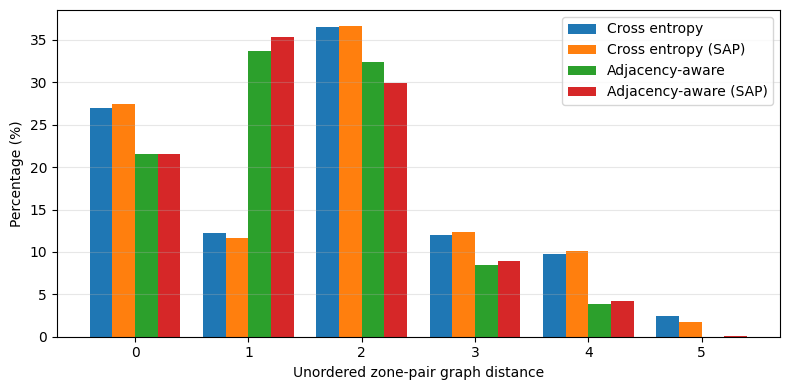

In [17]:
baseline_prediction_df = collect_where_predictions(
    where_transformer,
    test_where_dataset,
    DEVICE,
)

baseline_sap_df = collect_where_predictions(
    where_transformer_sap,
    test_where_dataset,
    DEVICE,
)

adjacency_prediction_df = collect_where_predictions(
    adjacency_where_transformer,
    test_where_dataset,
    DEVICE,
)

adjacency_prediction_sap_df = collect_where_predictions(
    adjacency_where_transformer_sap,
    test_where_dataset,
    DEVICE,
)


baseline_pair_distances = np.asarray(
    [
        unordered_pair_graph_distance(
            (row.true_from_zone, row.true_to_zone),
            (row.pred_from_zone, row.pred_to_zone),
            zone_distance_lookup,
        )
        for row in baseline_prediction_df.itertuples(index=False)
    ],
    dtype=float,
)
baseline_pair_distances_sap = np.asarray(
    [
        unordered_pair_graph_distance(
            (row.true_from_zone, row.true_to_zone),
            (row.pred_from_zone, row.pred_to_zone),
            zone_distance_lookup,
        )
        for row in baseline_sap_df.itertuples(index=False)
    ],
    dtype=float,
)
adjacency_pair_distances = np.asarray(
    [
        unordered_pair_graph_distance(
            (row.true_from_zone, row.true_to_zone),
            (row.pred_from_zone, row.pred_to_zone),
            zone_distance_lookup,
        )
        for row in adjacency_prediction_df.itertuples(index=False)
    ],
    dtype=float,
)
adjacency_pair_distances_sap = np.asarray(
    [
        unordered_pair_graph_distance(
            (row.true_from_zone, row.true_to_zone),
            (row.pred_from_zone, row.pred_to_zone),
            zone_distance_lookup,
        )
        for row in adjacency_prediction_sap_df.itertuples(index=False)
    ],
    dtype=float,
)


baseline_summary = summarize_pair_distances(baseline_pair_distances)
baseline_summary["exact_pair_accuracy"] = baseline_prediction_df[
    "exact_pair_match"
].mean()

baseline_summary_sap = summarize_pair_distances(baseline_pair_distances_sap)
baseline_summary_sap["exact_pair_accuracy"] = baseline_sap_df["exact_pair_match"].mean()

adjacency_summary = summarize_pair_distances(adjacency_pair_distances)
adjacency_summary["exact_pair_accuracy"] = adjacency_prediction_df[
    "exact_pair_match"
].mean()
adjacency_summary["mean_distance_reduction_vs_cross_entropy"] = 1 - (
    adjacency_summary["mean_distance"] / baseline_summary["mean_distance"]
)

adjacency_summary_sap = summarize_pair_distances(adjacency_pair_distances_sap)
adjacency_summary_sap["exact_pair_accuracy"] = adjacency_prediction_sap_df[
    "exact_pair_match"
].mean()
adjacency_summary_sap["mean_distance_reduction_vs_cross_entropy"] = 1 - (
    adjacency_summary_sap["mean_distance"] / baseline_summary_sap["mean_distance"]
)

adjacency_comparison_df = pd.DataFrame(
    [
        {"model": "Cross entropy", **baseline_summary},
        {"model": "Cross entropy (SAP)", **baseline_summary_sap},
        {"model": "Adjacency-aware", **adjacency_summary},
        {"model": "Adjacency-aware (SAP)", **adjacency_summary_sap},
    ]
)

display(adjacency_comparison_df.round(3))
print(
    "Adjacency-aware mean unordered pair distance reduction vs cross entropy: "
    f"{adjacency_summary['mean_distance_reduction_vs_cross_entropy']:.1%}"
)
print(
    "Adjacency-aware (SAP) mean unordered pair distance reduction vs cross entropy: "
    f"{adjacency_summary_sap['mean_distance_reduction_vs_cross_entropy']:.1%}"
)

bins = np.arange(-0.5, zone_graph_diameter + 1.5, 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = 0.2
baseline_counts, _ = np.histogram(
    baseline_pair_distances[np.isfinite(baseline_pair_distances)], bins=bins
)
baseline_sap_counts, _ = np.histogram(
    baseline_pair_distances_sap[np.isfinite(baseline_pair_distances_sap)], bins=bins
)
adjacency_counts, _ = np.histogram(
    adjacency_pair_distances[np.isfinite(adjacency_pair_distances)], bins=bins
)
adjacency_sap_counts, _ = np.histogram(
    adjacency_pair_distances_sap[np.isfinite(adjacency_pair_distances_sap)], bins=bins
)
baseline_percentages = 100 * baseline_counts / baseline_counts.sum()
baseline_sap_percentages = 100 * baseline_sap_counts / baseline_sap_counts.sum()
adjacency_percentages = 100 * adjacency_counts / adjacency_counts.sum()
adjacency_sap_percentages = 100 * adjacency_sap_counts / adjacency_sap_counts.sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    bin_centers - 1.5 * bar_width,
    baseline_percentages,
    width=bar_width,
    label="Cross entropy",
    align="center",
)
ax.bar(
    bin_centers - 0.5 * bar_width,
    baseline_sap_percentages,
    width=bar_width,
    label="Cross entropy (SAP)",
    align="center",
)
ax.bar(
    bin_centers + 0.5 * bar_width,
    adjacency_percentages,
    width=bar_width,
    label="Adjacency-aware",
    align="center",
)
ax.bar(
    bin_centers + 1.5 * bar_width,
    adjacency_sap_percentages,
    width=bar_width,
    label="Adjacency-aware (SAP)",
    align="center",
)
ax.set_xticks(bin_centers)
ax.set_xlabel("Unordered zone-pair graph distance")
ax.set_ylabel("Percentage (%)")
# ax.set_title("Cross-entropy vs adjacency-aware graph-distance error")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "where_cross_entropy_vs_adjacency_graph_distance_error.pdf",
    dpi=300,
)
plt.show()